In [49]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split,cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

In [50]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//nonlinear_regression_dataset.csv")
df.head()
x = df.drop(columns=['target'])
y = df['target']

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
pca = PCA(n_components=1)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

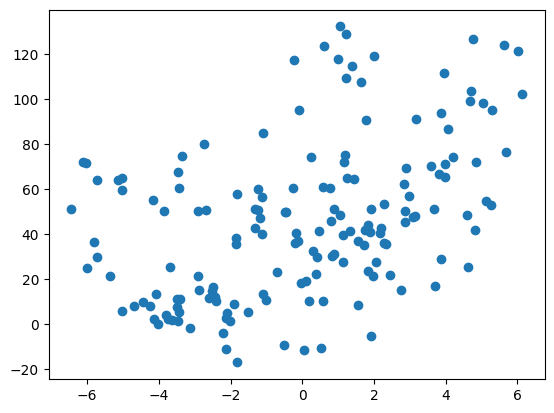

In [53]:
plt.scatter(x_train,y_train)

In [54]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regression(regressor, X, y):
    idx = np.argsort(X[:, 0])
    X_sorted = X[idx]

    plt.figure(figsize=(7,5))
    plt.scatter(X, y, label="Data")
    plt.plot(X_sorted,
        regressor.predict(X_sorted),
        linewidth=1,
        label="Regression",c='r'
        )

    plt.legend()
    plt.show()

In [55]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)
cv = cross_val_score(dt,x_train,y_train,cv=7,scoring='r2')
print(f"The cv score(r2) for dt is {np.mean(cv)}")
print(f"on test set , r2 score is {r2_score(y_test,dt.predict(x_test))}")

The cv score(r2) for dt is -0.24754733080153873
on test set , r2 score is -0.4567200580769164


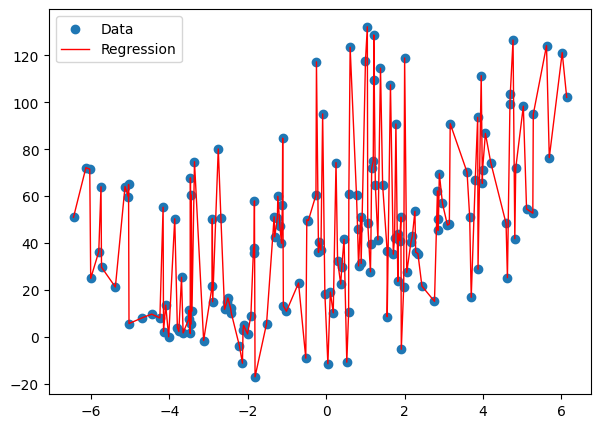

In [56]:
plot_regression(dt,x_train,y_train)

In [57]:
bagging = BaggingRegressor(estimator=None,random_state=42)
param_grid = {
    'n_estimators' : [50,100,200,300],
    'max_samples' : [0.25,0.4,0.5,0.6],
    'bootstrap' : [True,False]
}
grid = GridSearchCV(estimator=bagging,param_grid=param_grid,cv=7,scoring='r2',n_jobs=-1)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingRegres...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_samples': [0.25, 0.4, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [58]:
print(f"Best parameters : {grid.best_params_}")
print(f"Best cv score : {grid.best_score_}")

Best parameters : {'bootstrap': True, 'max_samples': 0.25, 'n_estimators': 50}
Best cv score : 0.15942525780104397


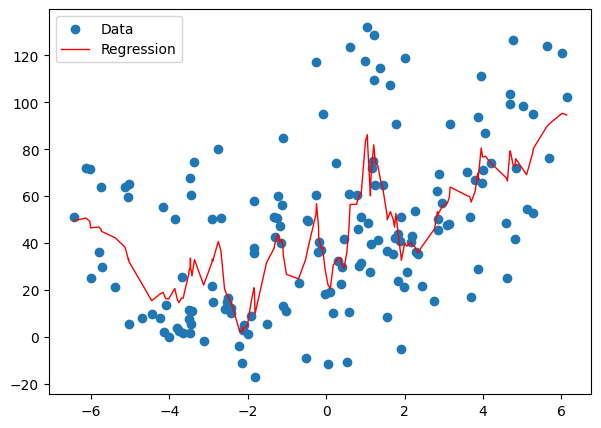

In [59]:
best_bag = BaggingRegressor(estimator=None,random_state=42,bootstrap=True,max_samples=0.25,n_estimators=50)
best_bag.fit(x_train,y_train)
plot_regression(best_bag,x_train,y_train)